# LAB 1 -- DAY 3B -- GRUBBS TEST FOR POTENTIAL OUTLIERS

When conducting an experiment, the goal is to collect reliable data. However, not every data point is perfect. Sometimes things happen, and these 'things' fall into two categories:

*   We **know** something went wrong
*   We **suspect** something went wrong

If you know something went wrong (you put your boogers in your sample, you used a different bottle of reagent on your 10th sample that was expired), you should **always** discard those points.

If you suspect something went wrong (maybe someone else put boogers in your sample or switched your bottle of reagent without you noticing), then you should use the Grubbs test.

Grubbs test checks whether the most extreme value in a dataset (minimum or maximum value) is significantly different from the rest of the data. If it is, it may be removed. If not, it must be kept.

Make sure to run all cells before starting so all functions are available. You will only need to modify cells marked with TODO.

Each TODO corresponds to a specific step in the Grubbs test process. Follow the instructions carefully and replace placeholders as directed.

# Steps

1. Add the data to a list (can be manually done or automated)
2. Calculate $G_{calc}$ by finding different statistics (avg, sd, min, and max) and determining the outlier
3. Calculate $G_{table}$ by finding $t_{table}$
4. Based on $G_{calc}$ and $G_{table}$, determine if the data point can safely be discarded or if it should be kept (at most ONE can be discarded)
5. If you discarded a data point, you must recalculate the average and standard deviation

In [1]:
# first we are going to add our 20 detector responses from 20 samples of unknown concentration into our data list
# refer to the grubbs.csv (excel or sheet) file for the values
# copy ('ctrl' + 'shift' + 'v"), paste, and separate values with commas
# list syntax: list_name = [item1, item2]

# TO DO [+1 pt]
# 1. put values in order from excel to data_list [+1 pt]
data_list = None

# printing data list for reference
print(data_list)

# don't forget to run all cells, especially after you modify them!!!!!!!
# either press the run button or 'ctrl' + 'enter'

None


## Did you know there's an easier way to add data to a list

Instead of manually adding each data point, because let's be for real, when you get to data sets with over hundreds of points (honestly even over 30), you're going to wish you were doing ANYTHING else.

Instead, we can import data directly from a CSV file and automatically store it in a list. This approach is faster, more scalable, and less prone to human error.

In the next section, we will use a *for loop* (remember from calibration_curves) and Python's built-in csv library to read the file line-by-line and store the values in a list.

FIRST, we need to to import a file. Google colab makes this easy with just two lines of code.

In [2]:
# importing a file from your computer
# using one of google colab's libraries
from google.colab import files

# files.upload() opens a file picker so you can upload a (CSV) file from your computer
# the uploaded file is stored in the Colab session so Python can read the data inside it
# note: you only have to upload once. after that, it should save the file and you can press "cancel upload" to skip this step
# in the case it doesn't save the file, then just reupload.
uploaded = files.upload()

# TO DO [+1 pt]
# click run -> choose files -> select 'grubbs.csv' [+1 pt]
# after it uploads successfully, continue running the remaining cells

## Reading the CSV file we just uploaded

Steps for this:
1. Import the csv library so we can read data from a CSV file
2. Create an empty list to store the values from the file
3. Open the CSV file using: **with open("file_name", "r") as f:**
    * "r" means we are opening the file in read mode, so we can view its contents without changing them
    * f is a variable that represents the opened file and is used to read the data inside it
4. Use the **csv.reader(f)** function from the csv library to read the file one row at a time
5. Each row of the CSV file is read one at a time, allowing us to process every value using a *for loop*
6. Convert each value from text to a number using **float()**, then store it in data_list with **append()**:

        data_list.append(float(row[0]))

Let's break down **data_list.append(float(row[0]))**:
* row[0] gets the value from the first column of the current row
* if the file had multiple columns, you could access them with row[1], row[2], and so on
* values read from a CSV file are stored as text (strings), so we use **float()** to convert them into decimal numbers before doing calculations
* **append()** adds each converted value to the end of data_list

Although this requires more code than typing values into a list manually, it is much faster and more efficient for large datasets. Whether the file contains 10 values or 10,000 values, the same code will read all of the data automatically.

In [3]:
# 1. importing csv so we can read our file
import csv

# 2. creating a data_list to store our values
data_from_csv = []

# 3. reading the file line by line and adding each value to data list
# note: if this doesn't work, check the file name is correct. feel free to update if needed
with open("grubbs.csv", "r") as f:      # opening "grubbs.csv" in read mode using f to call our file

    # 4. uses csv library to read our file f and put into variable called data
    data = csv.reader(f)

    # 5. we are looping through each row in our data.
    for row in data:

      # 6. adding the data (row[0]) into our data list
      data_from_csv.append(float(row[0]))

# printing our data_list to confirm it's the same as the one created above
print(data_from_csv)

[346.05, 360.48, 368.74, 309.86, 404.23, 377.13, 356.76, 321.55, 391.55, 374.58, 375.25, 370.33, 345.59, 371.09, 390.87, 305.41, 362.44, 383.93, 340.39, 359.94]


## Now that we have all the data, how do we calculate G$_{calc}$ ?

$$G_{calc} = \frac{|x - \bar{x}|}{s}$$

where:
* $x$ = potential outlier to be tested (either min or max, whatever is farthest from average)
* $\bar{x}$ (x_bar) = average of the dataset
* $s$ = sample standard deviation


## We are going to use functions to calculate the statistics needed

To compute the Grubbs test, we need several statistical values:
* mean (average)
* standard deviation
* minimum and maximum values

To avoid repeating code, we use functions.

A function is a reusable block of code that performs a specific task. Instead of rewriting the same logic multiple times, we define it once and call it whenever needed.

Functions in python look like the following:

```
def function_name(parameters):  # parameters are inputs to the function (optional)
  # function logic              # can be 1 line of code (like a print statement) or can be various lengths depending on functionality needed
  return value                  # return sends a result back to the user (optional)
```

You call a function by passing in a list (or values) and storing the result:

Example:

    avg = average(data_list)        # stores the computed average so it can be used later.

Note: You do not need to modify these functions. Your task is to use understand what they do/return and correctly use them in later steps.

In [4]:
# @title average(data_list)
def average(data_list):
  sum = 0                       # init sum to 0
  data_length = len(data_list)  # find number of values in list

  # sum up each value in data_list
  for i in range(data_length):
    sum += data_list[i]         # sum = sum + data_list[i]

  # find the average of the data list
  average = sum / data_length

  # returns average
  return average

In [5]:
# @title sample_sd(data_list)
import math                         # to take square root

def sample_sd(data_list):
  sum_of_deviances = 0              # initialize sum to 0
  data_length = len(data_list)      # find length of data

  # calculate average
  avg = average(data_list)          # use function we made to find average

  # find deviations from mean for each data point
  for i in range(data_length):
    deviation = data_list[i] - avg  # subract mean from each data point
    squared_d = (deviation ** 2)    # square the deviation to ensure all positive values
    sum_of_deviances += squared_d   # sum all squared deviations

  # divide sum by (n-1) where n is the data_length
  variance = sum_of_deviances / (data_length - 1)

  # take square root to give sample standard deviation and return it
  sample_sd = math.sqrt(variance)
  return sample_sd

In [6]:
# @title minimum(data_list)
def minimum(data_list):
  # initializes min value to first value in data_list
  min = data_list[0]

  # loops through each value in data_list
  for i in range(len(data_list)):
    # if the current data value is less than the min, update min value
    if data_list[i] < min:
      min = data_list[i]

  # return min value
  return min

In [7]:
# @title maximum(data_list)
def maximum(data_list):
  # initializes max value to first value in data_list
  max = data_list[0]

  # loops through each value in data_list
  for i in range(len(data_list)):
    # if the current data value is greater than the max, update max value
    if data_list[i] > max:
      max = data_list[i]

  # return max value
  return max

In [8]:
# @title absolute(value1, value2)
def absolute(value1, value2):
  # finding value1 - value2
  result = value1 - value2

  # if result is negative, multiply by (-1) to make positive
  if result < 0:  # negative
    return result * (-1)

  # otherwise, it's already positive, and return result
  return result

## Let's find the values to solve for G$_{calc}$

To do this, use the following functions that were defined above:
* **average(data_list)** --> returns average of data_list
* **sample_sd(data_list)** --> returns sample standard deviation of data_list
* **minimum(data_list)** -> returns minimum value of data_list
* **maximum(data_list)** --> returns maximum value of data_list
* **absolute(value1, value2)** -> returns absolute value between two points

Note: the absolute function will be used a little later on


In [9]:
# use the first four functions defined above to find:
# avg, sd, min, and max values
# replace 'None' with the proper function name and parameter(s)

# TO DO [+4 pts]
# 1) find the average [+1 pt]
avg = None
# 2) find the standard deviation (sd) [+1 pt]
sd = None
# 3) find the minimum value of data list [+1 pt]
min_val = None
# 4) find maximum value of data list [+1 pt]
max_val = None

# prints values for all variables
print("avg =", avg)
print("sd =", sd)

# a way to combine strings and variables QUICKER is to use an f string
# this is done by: print(f"<message>") and within the message, use {variable} to put the variable values
# \n creates a new line so output is easier to read
print(f"min_val = {min_val} \nmax_val = {max_val}")

avg = None
sd = None
min_val = None 
max_val = None


## So which one is the outlier?

We have to determine which point (min or max) is farther away from the average.

You can do this by either:
* finding the absolute value between the average and min/max values using the **absolute(value1, value2)** function above
* subtracting both numbers from the average and determining which one has a larger gap

You will want to use the point that is farthest in the $G_{calc}$ equation.



In [10]:
# find the absolute values between the max value and average AND min value and average
# or subtract the two numbers (use variables for ease) and determine which has the larger gap
# replace 'None' with a valid way of finding the distances between the two values

# TO DO [+2 pts]
# 1) find distance between the min value and the average [+1 pt]
min_dist = None
# 2) find distance between the max value and the average [+1 pt]
max_dist = None

# printing values
print(f"distance between min and avg = {min_dist}")
print(f"distance between max and avg = {max_dist}")


# now we decide which value is the potential outlier
# the value that is FARTHER from the mean is the one we test in the grubbs formula
# hint: compare min_dist and max_dist and whichever is larger |x| determines the potential outlier
# remember use the actual point, and not the distance you just found

# TO DO [+2 pts]
# 1) put the farthest value (min or max variable) into potential_outlier [+2 pts]
potential_outlier = None

# print the potential outlier chosen
print(f"potential outlier = {potential_outlier}")

distance between min and avg = None
distance between max and avg = None
potential outlier = None


## Yay we have all our info, let's find G$_{calc}$ !

All you need to do is assign the variables in *G$_{calc}$ = $\frac{|x - x_{bar}|}{s}$* with the values you just found above.

* your variables : avg, sd, potential_outlier
* G$_{calc}$ variables : x, $x_{bar}$, s


Remember:
* x_bar is the average
* x is the potential outlier to be tested (either min or max, whatever is farthest from average)
* s is the sample standard deviation

The absolute function defined above will also be used to find the absolute value between x and $x_{bar}$.

* **absolute(value1, value2)** -> returns absolute value between two points


In [11]:
# replace 'None' and assign x, x_bar, and s accordingly

# TODO [+3 pts]
# 1) assign x correctly [+1 pt]
x = None
# 2) assign x_bar correctly [+1 pt]
x_bar = None
# 3) assign s correctly [+1 pt]
s = None


# solving for G_calc using absolute function and appropriate variables

# TODO [+3 pts]
# 1) find the correct value of G_calc [+ 3 pts]
G_calc = None

# printing g_calc value
print(f"g_calc = {G_calc}")

g_calc = None


## How do we calculate $G_{table}$?

$$G_{table} = \frac{(n-1)t_{table}}{\sqrt{n(n-2+t_{table}^2)}}$$

where:
* $n$ is number of observations
* $t_{table}$ is a number we will calculate (this usually comes from a table based on the normal distribution)

We'll use the function: **t_inv(probability, dof)** to find $t_{table}$. Feel free to take a look at the function logic by clicking '1 cell hidden' below.

In [12]:
# @title t_inv(probability, dof)
# importing stats t module in order to do t.inv function in excel
from scipy.stats import t

# takes probability and degrees of freedom and returns t_table value
def t_inv(probability, dof):
  t_table = t.ppf(probability, dof)   # uses scipy.stats.t.ppf (percent point function)
  return t_table                      # returns t_table


## First, let's find $t_{table}$

The following steps are used to find $t_{table}$:
1) assign 0.05 to a variable called alpha, this means 95% probability of something
2) find the length of the data set, n
3) find the significance value, sig_val = alpha / n
4) find the degrees of freedom, dof = n-2
5) find t_table with the function:

       t_inv(probability, dof) --> returns value of t_table where probability = 1 - sig_val


In [13]:
# 1. assign alpha
alpha = 0.05  # means a 95% probability of something

# 2. find n, the number of values in the data set
n = len(data_list)  # gives length of data set

# 3. find significance value --> alpha / n
# use variables already defined for ease
# TODO [+1 pt]
# 1) find sig_val [+1 pt]
sig_val = None

# 4. find degrees of freedom (dof)
# TODO [+1 pt]
# 1) find dof [+1 pt]
dof = None

# 5. find t_table using the function, t_inv(probability, dof) function
# refer to above for help with t_table
# TODO [+1 pt]
# 1) find t_table using the function [+1 pt]
t_table = None

# prints all values defined above
print(f"alpha = {alpha} \nn = {n} \nsig value = {sig_val} \ndof = {dof} \nt_table = {t_table}")

TypeError: object of type 'NoneType' has no len()

## Now, finding $G_{table}$

Remember the equation: $G_{table}$ = $\frac{(n-1)t_{table}}{\sqrt{n(n-2+t_{table}^2)}}$

Use the values *n* and *t_table* you just found to solve for $G_{table}$.

Note:
* to multiply, you need '$*$', parenthesis alone won't work: (3)*(2) => 6
* to find the square root, use 'math.sqrt' : math.sqrt(9) => 3
* to square a value, use '$**$' : 3**2 => 9
* make sure to use () when needed to preserve order of operations noted in the equation

**import math** : needed when using math functions. This was already imported earlier with the functions, so no need to import it again, just keep in mind in the future you need to import the math library before using its functions.


In [ ]:
# break the equation up into numerator and denominator
# feel free to make extra intermediate variables to simplify calculations

# TODO [+3 pts]
# 1) find the numerator [+1 pt]
numerator = None
# 2) find the denominator [+2 pts]
denominator = None

# using numerator and denominator to find G_table
# this value needs to be correct for full credit [+4 pts]
G_table = numerator / denominator

# printing the value of G_table
print(f"G_table = {G_table}")

## Based on the results of $G_{calc}$ and $G_{table}$:
* if $G_{calc} \geq G_{table}$ : data point, x, is an outlier and we can discard it
* if $G_{calc} \leq G_{table}$ : data point is NOT significantly different from the others and must be kept

Note:
* you can discard, at most, ONE data point
* after removing the outlier (if there is one), you must recalculate the average and standard deviation

In [ ]:
# determining which is larger, which you lowkey can just eyeball this
print(f"G_calc = {G_calc} \nG_table = {G_table}")

## Wait, how would we remove a data point from our list??

Just like we can add or append a value to the list, we can also remove a value. This is done by using: **list_name.remove(value)** where value can be the actual value or a variable containing the value (like 'x').

Another way to remove a value is using **list_name.pop()**. Keep in mind, this only removes the LAST value in a list instead of a specific value, but can be useful in the future when you need to remove the last item in a list without knowing it's value.

If you found you need to remove a data point, do so in the next code block. If not, leave blank.


In [ ]:

# create a copy of data list and (possibly) remove the outlier
# first copy the data into updated_list using data_list.copy()
# then remove value using updated_list.remove(value)
# if outlier doesn't need to be discard, then don't remove a value

# TODO [+2 pts]
# 1) copy data_list [+1 pt]
updated_list = None
# 2) remove outlier or leave blank if not needed [+1 pt]

# printing updated_list
print(f"updated_list = {updated_list}")

## One last thing....

If you removed a data point, don't forget you need to also recalculate your averages and sample standard deviation using the updated data list.

* **average(data_list)** --> returns average of data_list
* **sample_sd(data_list)** --> returns sample standard deviation of data_list

In [ ]:
# recalculate avg and sd
# use updated_list to calculate these stats

# TODO [+2 pts]
# 1) recalculate the average [+1 pt]
final_avg = None
# 2) recalculate the standard deviation [+1 pt]
final_sd = None

# printing (updated) values for the average and sample standard deviation
print(f"final_avg = {avg} \nfinal_sd = {sd}")

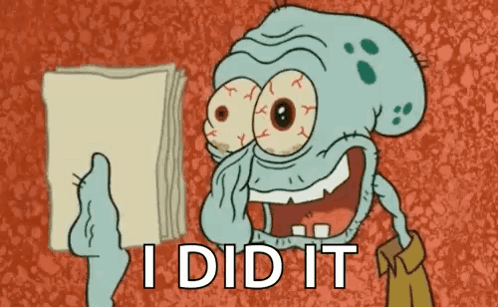